# Optimal Control
Knowing the dynamic model of an environment can be greatly useful for solving an RL problem. For instance, one can estimate the return of a policy parameter $\mathcal{J}_{\pi_{\theta}}$ with model predictions instead of querying the actual environments, which can be prohibitively expensive if a real physical process was involved. Many dynamic models like the one describing articulated robot arms are differential equations with a form like $\mathbf{\dot{x}} = f(\mathbf{x}, \mathbf{u})$. The return in this continuous time case is an integral of the reward at instaneous steps, which can be maximized as solving:

$$
\label{eq-rewardoptimctrl}
\begin{aligned}
& \arg\max\limits_{\theta} \int_{t=0}^T r(\mathbf{x}(t), \pi_{\theta}(\mathbf{x}(t)))dt \\
\text{s.t.} \quad & \mathbf{\dot{x}}(t) = f(\mathbf{x}(t), \pi_{\theta}(\mathbf{x}(t)))  \quad \forall t \in [0, T]   \\
\quad & \mathbf{x}(0) = \mathbf{x}_0
\end{aligned}
$$

The above equation is an instance of __optimal control__ of a continuous-time form and has a strong resemblance of the RL formulation. The notable distinction is that optimal control assumes knowing the environment transition as a dynamic constraint, while RL can only take samples from the transition that tends to be a discrete-time process. Optimal control also generally defines a terminal state reward term $\Phi(\mathbf{x}_T)$ in addition to $\int_{t=0}^T r(\mathbf{x}_t, \pi_{\theta}(\mathbf{x}_t))dt$. This is omitted here to align with the standard RL form. 

:::{note}
The transition process in [](#eq-rewardoptimctrl) is deterministic. There is also stochastic optimal control with process noise similar to the transition distribution in the standard RL. 
:::

The dynamic constraint implies that a state trajectory $\mathbf{x}(t)$ can be implicitly determined by $\theta$ if the composed right-hand side fulfils [certain conditions](https://en.wikipedia.org/wiki/Picard–Lindelöf_theorem). Hence, adopting $\theta^*$ to attain the optimal performance is equivalent to applying a trajectory of $\mathbf{u}^*(t)$ which should yield the optimal state trajectory $\mathbf{x}^*(t)$. Indeed, one can treat $\mathbf{u}(t)$ as a special form of $\pi$ that is parameterized as a time-dependent trajectory. Such a policy is called __open-loop__ control since it simply follows a plan no matter what $\mathbf{x}(t)$ it encounters during the execution. The policy like $\pi_{\theta}(\mathbf{x})$ is a type of __closed-loop__ control with a chance to react when $\mathbf{x}(t)$ deviates from the intended $\mathbf{x}^*(t)$, either due to an imprecise solution or the mismatch between the model and the real-world.

Comparing to learning $\pi_{\theta}$, searching $\mathbf{u}^*(t)$ and $\mathbf{x}^*(t)$ is usually much more tractable. This process is called __trajectory optimization__. Trajectory optimiztion can also be leveraged to "closed the loop", e.g. by designing $\pi{(\mathbf{x})} = \text{TrajOpt}(\mathbf{x})(0)$. Here we assume the trajectory optimization is solved by calling a function `TrajOpt` which takes the input as $\mathbf{x}_0$ and returns the optimal control trajectory $\mathbf{u}^*$ for the next $T$ interval. The policy can thus treat the current state $\mathbf{x}$ as the initial condition of the trajectory optimization and suggest to execute the first action $\mathbf{u}(0)$ while re-optimize everything when the next $\mathbf{x}$ arrives. This strategy, named __model predictive control__, has been the workhorse method for many cases of robot control, thanks to the rapid trajectory optimization nowadays. 


## Direct Shooting for Trajectory Optimization
Numerically, we can solve a trajectory optimization problem by discretizing the time horizon, turning it to a (possibly nonlinear) optimization:

$$
\label{eq-discretrajopt}
\begin{aligned}
& \arg\max\limits_{\mathbf{u}_{0:T-1}} \sum\limits_{t=0}^{T-1} r(\mathbf{x}_t, \mathbf{u}_t)\delta t \\
\text{s.t.} \quad & \mathbf{x}_{t+1} = \mathbf{x}_t + f(\mathbf{x}_t, \mathbf{u}_t) \delta t \quad \forall t = 0, 1, ..., T-1   \\
\end{aligned}
$$

<!-- 
$$
\label{eq-discreoptimctrl}
\begin{aligned}
& \arg\max\limits_{\theta} \sum\limits_{t=0}^{T-1} r(\mathbf{x}(t), \pi_{\theta}(\mathbf{x}(t)))\delta t \\
\text{s.t.} \quad & \mathbf{x}_{t+1} = \mathbf{x}_t + f(\mathbf{x}_t, \pi_{\theta}(\mathbf{x}_t)) \delta t \quad \forall t = 0, 1, ..., T-1   \\
\end{aligned}
$$ -->


Here $\mathbf{\dot{x}}_t$ is approximated with $\frac{\mathbf{x}_{t+1} - \mathbf{x}_t}{\delta t}$ and we abuse the notation of the whole time horizon now as $T\delta t$. The constraints here can be eliminated if we recursively substitute $\mathbf{x}_t$ with the result of $\mathbf{x}_t + f(\mathbf{x}_t, \mathbf{u}_t) \delta t$, ending up with an unconstrained optimization about $\theta = \mathbf{u}_{0:T-1}$. Following the recipe in [reinforcement learning](../1_RLSystem/notebooks.ipynb), we can shoot a guess of $\mathbf{u}_{0:T-1}$ and update $\mathbf{u}_{0:T-1}$ based on the evaluated return. With this in mind, we can use:
* Randomized search: sample a few $\mathbf{u}_{0:T-1}$ and re-fit the sampling distribution according to the return of each sample. This only requires taking samples following the dynamic constraint, making it actually closer to RL. Typical approaches include path-integral RL {cite:p}`pathintegral2010` and cross-entropy method {cite:p}`crossentropy2005`. 

* Gradient-based optimization: leverage the analytical model and derivatives to solve [](#eq-discretrajopt). This can be facilitated by efficient gradient evaluation from [auto-differentiation](../4_AutoDiff/notebooks.ipynb). 

Both cases concern the accuracy of $\mathbf{x}(t)$. The discretization above implies an explicit Euler integration of $\mathbf{\dot{x}}(t) = f(\mathbf{x}(t), \mathbf{u}(t))$. The accuracy of state trajectories and the return estimate depends on the size of time interval $\delta t$. As a simple example of $\dot{x} = x$, the solution of $x(t)$ is analytically available as $x(t) = e^tx_0$ so we may compare the accuracy obtained from different explicit time step $\delta t$, e.g. for $x_0=1$ and $T=2$:

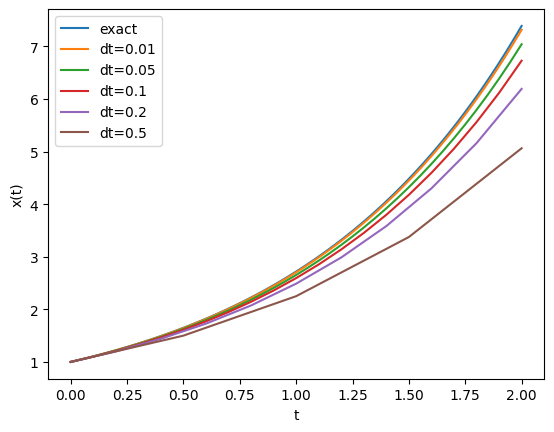

In [9]:
import numpy as np
import matplotlib.pyplot as plt
x0 = 1
T = 2
x_real = np.exp(np.linspace(0, T, 100)) * x0

delta_t = [0.01, 0.05, 0.1, 0.2, 0.5]

def euler_integrate(x0, T, dt):
    ret = [0], [x0]
    for _ in range(int(T / dt)):
        ret[0].append(ret[0][-1]+dt)
        ret[1].append(ret[1][-1]+ret[1][-1]*dt)
    return ret

x_approx_lst = [euler_integrate(x0, T, dt) for dt in delta_t]

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(np.linspace(0, T, 100), x_real, label="exact")

for dt, x_approx in zip(delta_t, x_approx_lst):
    ax.plot(x_approx[0], x_approx[1], label="dt={0}".format(dt))

ax.set_xlabel('t')
ax.set_ylabel('x(t)')
ax.legend(loc='upper left')
plt.show()

For a fixed horizon, a smaller $\delta t$ will yield more accuracy at the expense of more queries to $f$. Note that this not only implies more computational costs but also more memory consumption if reverse-mode auto-differentiation would be used. Thus it often benefits from advanced integration methods for a better trade-off between costs and accuracy. 

A slight modification to [](#eq-discretrajopt) is to keep the constraints while adding $\mathbf{x}_{1:T}$ as decision variables. This is formally equivalent to [](#eq-discretrajopt) and might appear not appealing for solving a constrained problem with more decision variables. However, simultanously solving both state and action creates less dependencies between decision variables and often results in more sparsity that can be exploited by solvers. We are now free to tackle [implicit dynamic constraints](https://en.wikipedia.org/wiki/Explicit_and_implicit_methods) where the next state may not be the result of an explicit Euler step. This form is called __direct transcription__. One may also take a middle ground, by breaking the entire shooting horizon into segments and imposing state constraints at the boundary points. This is called _multiple shooting_, in constrast to _single shooting_ that integrates the whole time horizon. In what follows, we stick to single shooting with the explicit Euler for simplicity. [The following module](../6_AdjointMethod/notebooks.ipynb) will discuss how to differentiate an implicit process. 

:::{note} Other direct methods
There are also methods irrelevant to how the state trajectory is integrated. The idea is to approximate $\mathbf{x}(t)$ and $\mathbf{u}(t)$ with parameterized trajectories, e.g. piece-wise polynomials whose time derivatives are readily available. The functions and derivatives are then evaluated at a few __collocation points__ which are now the decision variables. This turns differential constraints to equality constraints at these collocation points. The main issue here is whether the amount of collocation points and spline segments will be sufficient for an accurate approximation of the dynamic model. 
:::


## A Case on the Three-link Arm Model

Let's walk through a case of controlling a three-link robot arm to reach the tip to a point in the spatial space. Recall that the dynamics of articulated links are with a form $\mathbf{M}(\mathbf{q})\ddot{\mathbf{q}} + \mathbf{C}(\dot{\mathbf{q}}, \mathbf{q}) = \mathbf{B}\mathbf{\tau}$. We can have the state defined as $\mathbf{x} = [\mathbf{q}; \dot{\mathbf{q}}]$ and the control as $\mathbf{u} = \mathbf{\tau}$. This yields an equation:

$$
\label{eq-robotdyn}
\dot{\begin{bmatrix}
\mathbf{q}  \\
\dot{\mathbf{q}}
\end{bmatrix}} = \begin{bmatrix} \mathbf{0} & \mathbf{1} \\ \mathbf{0} & \mathbf{0} \end{bmatrix} \begin{bmatrix}
\mathbf{q}  \\
\dot{\mathbf{q}}
\end{bmatrix} + \mathbf{M}^{-1}(\mathbf{q}) \begin{bmatrix} \mathbf{0} \\  \mathbf{B}\mathbf{u} - \mathbf{C}(\dot{\mathbf{q}}, \mathbf{q}) \end{bmatrix}
$$

which fits the dynamic constraint form $\dot{\mathbf{x}} = f(\mathbf{x}, \mathbf{u})$ in trajectory optimization. To promote a state trajectory aligning the tip to a target, a larger reward will be allocated if the tip position is closer to the target position. The tip position can be calculated by following the forward kinematics and applying a translation relative to the pose of the last link. We just need to wire the results of each step and leave the derivative computation to auto-differentiation:


In [2]:
import os
os.environ['SIRL_USE_JAX'] = "1"
from articulated_dynamics.math_utils import nplib, rotate
from articulated_dynamics.dynamics import Dynamics, Kinematics
from articulated_dynamics.robots import ThreeLinks
from articulated_dynamics.integrator import integrate_euler

import jax

robot = ThreeLinks()

q0 = nplib.array([-nplib.pi/2, 0, 0])
qd0 = nplib.zeros(3)
x_goal = nplib.array([0.5, 0.5, 0])
dt = 0.01

@jax.jit
def simulate(init, u_traj):
    tol_cost = 0

    def sim_step(carry, ctrl):
        q, qd, cumcost = carry
        qdd = Dynamics.forward(robot, q, qd, ctrl)
        q_next, qd_next = integrate_euler(robot, dt, q, qd, qdd, symplectic=False)
        x_pose = Kinematics._forward_pos(robot, q_next)[0][-1]
        #get tip position
        xp_tip = x_pose.trans + rotate(nplib.array([0, 0.15, 0]), x_pose.rot)
        cumcost += nplib.sum(nplib.abs(xp_tip - x_goal))
        return (q_next, qd_next, cumcost), (q_next, qd_next)
    
    carry_init = (init[0], init[1], tol_cost)

    carry_final, sim_traj = jax.lax.scan(sim_step, carry_init, u_traj)
    return carry_final, sim_traj

def traj_cost(u_traj_flatten):
    u_traj = u_traj_flatten.reshape((-1, 3))
    
    final, sim_traj = simulate((q0, qd0), u_traj)
    
    #penalize aggressive control input and excessive joint velocity
    tol_cost = final[2] + nplib.sum(nplib.abs(u_traj)) * 1e-3 + nplib.sum(nplib.abs(sim_traj[1])) * 1e-2
    return tol_cost




Here we use JAX and leverage its `jit` decoration to compile the computation process. Notably, the loop over the time horizon $T$ is implemented as a [scan](https://jax.readthedocs.io/en/latest/_autosummary/jax.lax.scan.html) of the integration steps to further improve the efficiency. We adopt $\delta t = 0.01$ and penalize aggressive control efforts. This is usually used to yield smoother trajectories. Imagine that the optimizer is allowed to use arbitrarily large control, it might produce unrealistic accelerations to reach the goal as soon as possible because the mismatch at each time step accumulates. 

In [3]:
#solve the goal reaching task with gradient-based optimization
T=50
u_traj = nplib.zeros((T*3))

trajgrad = jax.grad(traj_cost)
jit_trajgrad = jax.jit(trajgrad)

print("Initial guess cost:", traj_cost(u_traj))
print("First call to JIT grad func to compile...")
jit_trajgrad(u_traj)
print("Finished compiling.")


Initial guess cost: 68.19042
First call to JIT grad func to compile...
Finished compiling.


We also run `jit` to the gradient obtained from JAX. The first time calling the "jitted" function will trigger the compilation, which may take a while depending on the function complexity. The compiled function can then be run pretty fast in the subsequent calls. The three-link arm gets {eval}`T` steps or say {eval}`T*dt` seconds to reach the goal. The optimizer is then tasked to search {eval}`T*3` decision variables. Again, we can simply plug the functions into `scipy.optimize.minimize` to solve the problem:

In [4]:
import scipy
result = scipy.optimize.minimize(traj_cost, u_traj, method="L-BFGS-B", jac=jit_trajgrad, options={"maxiter":1000, "disp":False, "gtol":1e-3})
print(result)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 17.721323013305664
        x: [ 4.283e+01  3.264e+01 ...  5.998e-01 -2.747e-01]
      nit: 153
      jac: [-6.239e-03 -6.520e-02 ...  3.038e-03  1.654e-03]
     nfev: 240
     njev: 240
 hess_inv: <150x150 LbfgsInvHessProduct with dtype=float64>


Such a problem can be solved lighting fast on a modern laptop. Let's visualize the goal and motion to check whether the motion result looks reasonable:

In [5]:
import articulated_dynamics.visualizer as viz
_, sim_traj = simulate((q0, qd0), result.x.reshape((-1, 3)))
viewer = viz.P3JSViewer(width=300, height=400)
viewer.create_shapes(robot)
viewer.place_shapes_qpos(robot, q0)
viewer.place_marker('goal', x_goal, scale=0.05)

#visualize the optimal trajectory, slow down the animation with 10x
anim_action = viewer.animate_qpos_traj(robot, sim_traj[0], dt*10)
viewer.show()
anim_action


Renderer(camera=PerspectiveCamera(aspect=0.75, children=(DirectionalLight(color='white', intensity=0.6, positi…

AnimationAction(clip=AnimationClip(duration=5.0, tracks=(VectorKeyframeTrack(name='scene/link_0.position', tim…

## Indirect Methods

Those who are familiar with numerical optimization might know that regular optimum must satisfy some necessary conditions, e.g. KKT condition, and may wonder whether there are something similar for $\mathbf{x}^*(t)$ and $\mathbf{u}^*(t)$. This is indeed the case for very general optimal control problems. These conditions are given as Pontrygin's maximum principles, named after the Soviet mathematician Lev Pontryagin. Specifically, for an optimal control problem similar to [](#eq-rewardoptimctrl):

$$
\label{eq-optimctrl}
\begin{aligned}
& \arg\min\limits_{\mathbf{x}(t), \mathbf{u}(t)} \Phi(\mathbf{x}(T)) + \int_{t=0}^T l(\mathbf{x}(t), \mathbf{u}(t))dt \\
\text{s.t.} \quad & \mathbf{\dot{x}}(t) = f(\mathbf{x}(t), \mathbf{u}(t))  \quad \forall t \in [0, T]   \\
\quad & \mathbf{x}(0) = \mathbf{x}_0
\end{aligned}
$$

which takes a form of minimization with $l(\mathbf{x}, \mathbf{u}) = -r(\mathbf{x}, \mathbf{u})$ and a terminal cost $\Phi(\mathbf{x}(T))$. Similar to Lagrangians in constrained optimization, we can define $H(\mathbf{x}, \mathbf{u}, \mathbf{\lambda}) = l(\mathbf{x}, \mathbf{u}) + \mathbf{\lambda}^\top f(\mathbf{x}, \mathbf{u})$, named _Hamiltonian_ and $\mathbf{\lambda}$ is called co-state or _adjoint state_. Pontryagin maximum principles say that an optimal state trajectory $\mathbf{x}^*(t)$ starting from $\mathbf{x}_0$ satisfies:

$$
\label{#eq-pmp}
\begin{aligned}
\dot{\mathbf{x}} & = \frac{\partial H(\mathbf{x}, \mathbf{u}, \mathbf{\lambda})}{\partial \mathbf{\lambda}} = f(\mathbf{x}, \mathbf{u}) \\
-\dot{\mathbf{\lambda}}^\top & = \frac{\partial H(\mathbf{x}, \mathbf{u}, \mathbf{\lambda})}{\partial \mathbf{x}} = \frac{\partial l(\mathbf{x}, \mathbf{u})}{\partial \mathbf{x}} + \mathbf{\lambda}^\top\frac{\partial f(\mathbf{x}, \mathbf{u})}{\partial \mathbf{x}}     \\
\mathbf{u} & = \arg\min\limits_{\mathbf{u}} H(\mathbf{x}, \mathbf{u}, \mathbf{\lambda}) \\ 
\end{aligned}
$$
with $\mathbf{\lambda}^\top(T) = \frac{\partial \Phi(\mathbf{x}(T))}{\partial \mathbf{x}}$. The first condition is the dynamic equation itself. The second condition is a differential equation about the time evolution of the Lagrangian multiplier $\mathbf{\lambda}$, called adjoint equation. The third condition can also be an equation as $\frac{\partial H(\mathbf{x}, \mathbf{u}, \mathbf{\lambda})}{\partial \mathbf{u}} = 0$ if Hamiltonian is differentiable and $\mathbf{u}$ is unconstrained. One can hence solve the above equations with boundary conditions about $\mathbf{x}(0)$ and $\mathbf{\lambda}(T)$ for the optimal state trajectory and control. This is called indirect method in contrast to direct methods like shooting. One way to see their relation is that direct methods perform time discretization to transcript optimal control to numerical optimization (first discretize then optimize), while indirect methods derive the optimality conditions of the continuous trajectories and then resort to solving differential equation which usually involves discretization (first optimize then discretize). 

In particular, consider quadratic instaneous cost and linear dynamic constraints:

$$
\label{#eq-lqr}
\begin{aligned}
& \arg\min\limits_{\mathbf{x}(t), \mathbf{u}(t)} \mathbf{x}^{\top}(T)P\mathbf{x}(T) + \int_{t=0}^T (\mathbf{x}^{\top}(t)Q(t)\mathbf{x}(t) + \mathbf{u}^{\top}(t)R(t)\mathbf{u}(t))dt \\
\text{s.t.} \quad & \mathbf{\dot{x}}(t) = A(t)\mathbf{x}(t) + B(t)\mathbf{u}(t) \\
\quad & \mathbf{x}(0) = \mathbf{x}_0
\end{aligned}
$$

Because of these special forms the problem is called LQR (Linear-Quadratic-Regulation) for regulating the state subject to a linear dynamic constraint towards the origin. Pontryagin's maximum principles imply $\mathbf{u}^*(t) = -\frac{1}{2}R^{-1}(t)B^{\top}(t)\mathbf{\lambda}$ with

$$
\label{#eq-ricatti}
\begin{aligned}
-\dot{\mathbf{\lambda}} & = 2Q(t)\mathbf{x}(t) + A^{\top}(t)\mathbf{\lambda}  \\
\mathbf{\lambda}(T) & = 2P\mathbf{x}(T)
\end{aligned}
$$

This is a linear [Riccati equation](https://en.wikipedia.org/wiki/Riccati_equation) with $\mathbf{\lambda}$, which can be easily solved backwardly from $\mathbf{\lambda}(T)$. It is not hard to see that $\mathbf{\lambda}$ follows a form linear with $\mathbf{x}$, i.e. $\mathbf{\lambda}(t) = 2S(t)\mathbf{x}(t)$. Thus, the optimal control is also linear with the state as $\mathbf{u}^*(t) = -R^{-1}(t)B^{\top}(t)S(t)\mathbf{x}(t)$. Recall that we usually construct state with position and its derivative, such as $\mathbf{x} = [\mathbf{q}; \dot{\mathbf{q}}]$. The control can be seen as the linear combination of position and its derivative, which can be simply written as:

$$
\label{#eq-pdctrl}
\begin{aligned}
\mathbf{u}(t) = -K(t)\mathbf{q} - D(t)\dot{\mathbf{q}}
\end{aligned}
$$

In control application, such a form is called PD (Proportion-Derivative) control and is probably the most used form of control law to steer $\mathbf{q}$ and $\dot{\mathbf{q}}$ towards zero or certain value if an offset is used. One may find that PD control resembles a spring-like behaviour. Indeed, a larger $K$ suggests correcting more aggressively when $\mathbf{x}$ is deviating from the rest position (zero in this case). $D$ acts as viscosity to drag down the system speed and is often called the damping term. Hence a similar form is also sometimes called stiffness control or impedance control in the context of robot force control.

The LQR form does not only provide insights on what optimal control looks like for certain problems, but also implies a way to solve [](#eq-optimctrl). For instance, if we have a guess of $\mathbf{u}^*(t)$ as $\mathbf{u}^k(t)$, we can:

* run the forward simulation to obtain $\mathbf{x}^k(t)$. 
* approximate $l(\mathbf{x}, \mathbf{u})$ and $f(\mathbf{x}, \mathbf{u})$ with Taylor's expansion and obtain an LQR. 
* solve the LQR and get an improved guess $\mathbf{u}^{k+1}(t)$
* repeat until $\mathbf{x}^k(t)$, $\mathbf{u}^k(t)$ and $\mathbf{\lambda}^k(t)$ agree upon the Pontryagin's maximum principles. 

Popular algorithms like iterative-LQR (iLQR) {cite:p}`ilqr2004` follow such a scheme and have been extensively used alongside direct methods. The Taylor expansion relies on evaluating derivatives like $\frac{\partial f(\mathbf{x}, \mathbf{u})}{\partial \mathbf{x}}$ so the auto-differentiation techniques can also be relevant here. 

## More on Optimal Control and Relevant Software

It is obvious that optimal control shares many similarities to reinforcement learning. Quite a few of theories, algorithms and tools are developed from different domains and as a result, may follow different terms and conventions. To describe the stocasticity in RL transition, optimal control has the variant called _stochastic optimal control_ which tackles stochastic dynamic processes and statistics of the rollout return, e.g.:

$$
\label{eq-stocoptimctrl}
\begin{aligned}
& \arg\max\limits_{\theta} \mathbb{E}_{\mathbf{x}(0) \sim p_0(\mathbf{x})} [ \int_{t=0}^T r(\mathbf{x}(t), \pi_{\theta}(\mathbf{x}(t)))dt ]\\
\text{s.t.} \quad & d\mathbf{x}(t) = f(\mathbf{x}(t), \pi_{\theta}(\mathbf{x}(t)))dt + \mathbf{w}(t)  \quad \forall t \in [0, T]   \\
\end{aligned}
$$

where $\mathbf{w}(t)$ is a stochastic process such as [Wiener process](https://en.wikipedia.org/wiki/Wiener_process). The statistics can be other than just taking the mean of the return to account for higher-order terms. For instance, we can also add the return _variance_ with some negative coefficient, to express that the policy is _risk-averse_. Many approaches covered in this module has a version for stochastic optimal control as well.

The way of calculating the trajectory return can also be more involved than a plain summation. For instance, a goal-directed behaviour is usually charactersied by something like $\| \mathbf{x}(t) - \mathbf{g} \|$, measuring how far the current state $\mathbf{x}(t)$ is from the goal $\mathbf{g}$. The norm here can be of many choices beyond the basic $2$-norm. We may take $\infty$-norm i.e. $\text{max}(\cdot)$ to optimize the worst-case performance. In particular, it is possible to define an optimal control problem like:

$$
\label{eq-robustoptimctrl}
\begin{aligned}
& \arg\max\limits_{\theta} [ \min\limits_{w \in \mathcal{W}}\int_{t=0}^T r(\mathbf{x}(t), \pi_{\theta}(\mathbf{x}(t)))dt] \\
\text{s.t.} \quad & \mathbf{\dot{x}}(t) = f(\mathbf{x}(t), \pi_{\theta}(\mathbf{x}(t)), w)  \quad \forall t \in [0, T]   \\
\quad & \mathbf{x}(0) = \mathbf{x}_0
\end{aligned}
$$

where the entire inner $\min$ defines the new return, with $w \in \mathcal{W}$ playing the role of an _adversary_ to challenge the policy. This adversarial-like training can give us something expected to work well in face of disturbances and hence called _robust_ optimal control. The new formulation is surely more complicated to evaluate the return and its proper gradients.

Optimal control traditionally found its main usage in the process control of chemical engineering. The workhorse methods are largely about transcripting and solving nonlinear optimization problems so one can select favourite optimization packages to build their own solution. There are also more self-contained software libraries, such as [OpenDymos](https://github.com/OpenMDAO/dymos), [CasADi](https://web.casadi.org/blog/ocp/) and [Drake](https://drake.mit.edu).

